# 07 — Skeleton (interpolative) decomposition of Aurora's backbone hidden states

**Case**: Typhoon Bebinca, init=2024-09-15T00:00, 4 rollout steps of 6h (valid +6h..+24h), China region.

## Aurora architecture (where exactly we hook)

Aurora = **encoder** (Perceiver-style module that compresses per-variable, per-pressure-level
physical fields into a compact 2D grid of tokens) → **backbone** (a 3D Swin-Transformer U-Net:
here 3 encoder-path stages that progressively halve spatial resolution via patch merging
while doubling channel width, followed by 3 decoder-path stages that upsample back with skip
connections — see `aurora/model/swin3d.py: Swin3DTransformerBackbone`) → **decoder**
(Perceiver-style expansion of backbone tokens back into physical variables/levels, predicting
a delta added to the previous state).

The **Advection Heads** paper studies the backbone's window-**attention weight matrices**
(the Q-K routing — *how* information moves between tokens) and finds heads whose attention
offset matches the local wind field (semi-Lagrangian-like advection).

Here we study something different: not *how* information is routed, but *what* is represented.
We hook `model.backbone.encoder_layers[i]` (i = 0, 1, 2 for this checkpoint) with forward
hooks and capture the **residual-stream hidden state** (token matrix) at the output of each
encoder-path stage:

- **stage 0**: finest resolution, closest to the raw encoded field, smallest receptive field.
- **stage 1**: intermediate resolution.
- **stage 2**: bottleneck — coarsest resolution, no further downsampling, maximal receptive
  field / most globally-mixed representation across the whole domain.

## Skeleton / interpolative decomposition

For each stage and lead time we have a token matrix `X` of shape `(H*W, D)` (spatial locations
× channels; a small Perceiver pseudo-level dimension is averaged out for 2D visualization).
Unlike SVD/PCA, an **interpolative (skeleton) decomposition** picks `k` *actual* rows or
columns of `X` as the basis — no abstract linear combinations. We compute two one-sided
decompositions with `scipy.linalg.interpolative.interp_decomp` (rank-revealing QR, numerically
stable):

- **row skeleton**: `k` representative *grid points* ("landmarks") such that every other grid
  point's feature vector is a linear combination of the landmarks' feature vectors. If these
  landmarks cluster at the storm center / front / jet axis, that is direct evidence the model's
  internal representation treats those locations as structurally load-bearing.
- **column skeleton**: `k` representative *channels* such that every other channel's spatial
  map is a linear combination of the landmark channels' maps — a way to find a small
  non-redundant subset of the (otherwise anonymous) hidden channels.

Reconstruction fidelity (`rel_error`) as a function of `k`, stage, and lead time tells us how
compressible the representation is — directly relevant to the "can we simplify/speed up
inference" question: if a handful of landmarks reconstructs the hidden state well, a rollout
could in principle propagate only those landmarks (sparse state), which would address the
~8GB unexplained memory overhead we found earlier in `aurora.rollout()`. Landmarks are also a
natural, principled guide for *where* to run cheap occlusion experiments instead of occluding
the full grid.

Data for this notebook was produced by `run_skeleton_case.py` (hooks + rollout + decomposition,
`k=24` landmarks) and saved to `results/skeleton_decomposition/bebinca_aurora.pkl`.

In [1]:
import pickle
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

plt.rcParams['figure.dpi'] = 110

DATA_ROOT = '/srv/exw/data/irina_weather_interpretability'
RESULTS_PATH = os.path.expanduser('~/weather-interpretability/results/skeleton_decomposition/bebinca_aurora.pkl')
FIG_DIR = 'figures/07_skeleton_decomposition'
os.makedirs(FIG_DIR, exist_ok=True)

INIT_TIME = np.datetime64('2024-09-15T00:00')
CHINA_EXTENT = [95, 130, 15, 45]

with open(RESULTS_PATH, 'rb') as f:
    results = pickle.load(f)

K = results['k']
STAGE_RES = results['stage_res']  # input resolution to each stage, (C, H, W)
stages = sorted(results['stages'].keys())
STAGE_LABELS = {stages[0]: 'Stage 0 (finest)', stages[-1]: 'Stage %d (bottleneck)' % stages[-1]}
for s in stages:
    STAGE_LABELS.setdefault(s, f'Stage {s}')
print('Stages:', stages, 'k =', K)
print('Backbone input resolutions per stage (C,H,W):', STAGE_RES)

Stages: [0, 1, 2] k = 256
Backbone input resolutions per stage (C,H,W): [(4, 180, 360), (4, 90, 180), (4, 45, 90)]


In [2]:
ds_surf = xr.open_zarr(f'{DATA_ROOT}/era5_2024_2025_6h_surface.zarr', chunks=None)
ds_upper = xr.open_zarr(f'{DATA_ROOT}/era5_2024_2025_6h_upper.zarr', chunks=None)

lat_full = ds_surf.latitude.values  # 721 values, descending 90..-90
lon_full = ds_surf.longitude.values  # 1440 values, 0..360
# Aurora crops to a multiple of patch_size=4 along lat -> drops the last (south pole) row.
lat_crop = lat_full[:720]
lon_crop = lon_full  # 1440 already divisible by 4

PATCH_SIZE = 4


def stage_latlon(stage_idx):
    """Approximate lat/lon centers for a stage's OUTPUT token grid (used for landmark
    plotting). Stage output resolution: stage with downsample -> next entry in STAGE_RES;
    last (bottleneck) stage -> same entry as its own input (no further merge)."""
    last = stages[-1]
    res_idx = stage_idx if stage_idx == last else stage_idx + 1
    _, H_s, W_s = STAGE_RES[res_idx]
    factor_h = len(lat_crop) // H_s
    factor_w = len(lon_crop) // W_s
    lat_s = lat_crop[::factor_h][:H_s]
    lon_s = lon_crop[::factor_w][:W_s]
    return lat_s, lon_s, H_s, W_s


def get_truth_fields(valid_time):
    mslp = ds_surf.sel(time=valid_time)['mean_sea_level_pressure'].values / 100
    z850 = ds_upper.sel(time=valid_time, level=850)['geopotential'].values / 9.80665
    u850 = ds_upper.sel(time=valid_time, level=850)['u_component_of_wind'].values
    v850 = ds_upper.sel(time=valid_time, level=850)['v_component_of_wind'].values
    return mslp, z850, u850, v850


def relative_vorticity(u, v, lat, lon):
    """Simple centered-difference relative vorticity dv/dx - du/dy on a regular lat/lon grid."""
    R = 6.371e6
    dlat = np.deg2rad(lat[1] - lat[0])
    dlon = np.deg2rad(lon[1] - lon[0])
    dv_dx = np.gradient(v, axis=1) / (dlon * R * np.cos(np.deg2rad(lat))[:, None])
    du_dy = np.gradient(u, axis=0) / (dlat * R)
    return dv_dx - du_dy


LEAD_HOURS_LIST = results['stages'][stages[0]]
LEAD_HOURS_LIST = [d['lead_hours'] for d in LEAD_HOURS_LIST]
print('Lead times (h):', LEAD_HOURS_LIST)

Lead times (h): [6, 12, 18, 24]


## 1. Reconstruction fidelity vs stage and lead time

## 0. Choosing k: rank-vs-error sweep

Before picking a landmark budget k, we swept k over the cached raw hidden-state matrices
(no model rerun needed) and looked for where reconstruction relative error drops below a
0.15 target. There was no sharp knee -- error decreases smoothly with k -- but stage 0
(finest) crosses the 0.15 threshold around k~192-256, while the deeper stages 1/2
(bottleneck) do not reach it even at k=512. This itself is informative: **the bottleneck
representation resists linear/skeleton compression at reasonable budgets far more than the
finest stage does** -- consistent with the bottleneck packing much more into fewer, wider
channels. We chose **k=256** as a shared budget across stages (a reasonable point for stage
0, and a real but imperfect approximation for stages 1/2 -- reported error is shown
honestly in every figure below rather than hidden).

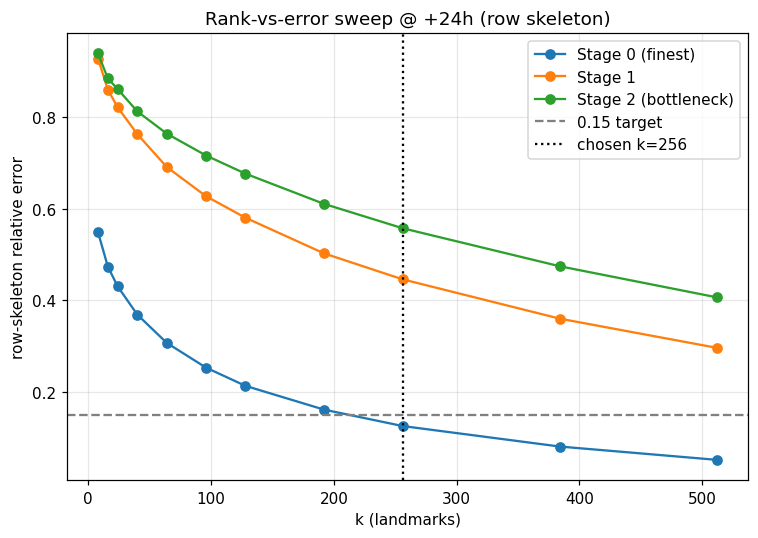

In [3]:
import scipy.linalg.interpolative as sli_sweep

RAW_X_PATH = os.path.expanduser('~/weather-interpretability/results/skeleton_decomposition/bebinca_aurora_raw_X.npz')
raw_X_data = np.load(RAW_X_PATH)
K_VALUES = [8, 16, 24, 40, 64, 96, 128, 192, 256, 384, 512]
STEP_IDX_FOR_SWEEP = 3  # +24h


def _rel_error_for_k(X64, k, transpose):
    A = X64.T if transpose else X64
    idx, proj = sli_sweep.interp_decomp(A, k)
    P = sli_sweep.reconstruct_interp_matrix(idx, proj)
    Xhat = (P.T @ X64[idx[:k], :]) if transpose else (X64[:, idx[:k]] @ P)
    return float(np.linalg.norm(Xhat - X64) / np.linalg.norm(X64))


fig, ax = plt.subplots(figsize=(7, 5))
for s in stages:
    X = raw_X_data[f'stage{s}_step{STEP_IDX_FOR_SWEEP}'].astype(np.float64)
    errs = [_rel_error_for_k(X, k, transpose=True) for k in K_VALUES]
    ax.plot(K_VALUES, errs, marker='o', label=STAGE_LABELS[s])
ax.axhline(0.15, color='gray', linestyle='--', label='0.15 target')
ax.axvline(K, color='black', linestyle=':', label=f'chosen k={K}')
ax.set_xlabel('k (landmarks)')
ax.set_ylabel('row-skeleton relative error')
ax.set_title('Rank-vs-error sweep @ +24h (row skeleton)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

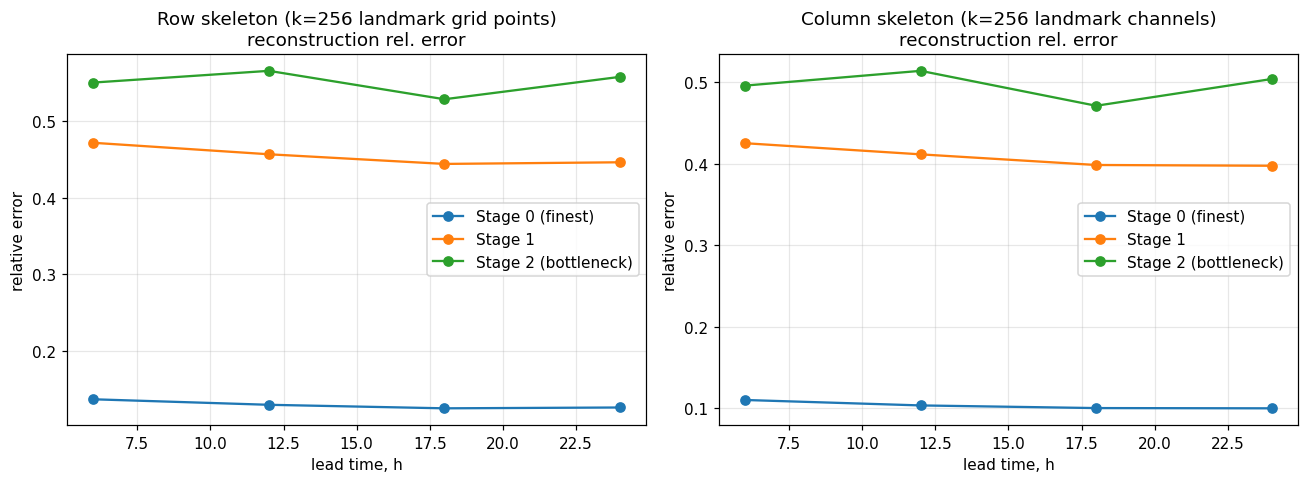

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for s in stages:
    leads = [d['lead_hours'] for d in results['stages'][s]]
    row_err = [d['row_rel_error'] for d in results['stages'][s]]
    col_err = [d['col_rel_error'] for d in results['stages'][s]]
    axes[0].plot(leads, row_err, marker='o', label=STAGE_LABELS[s])
    axes[1].plot(leads, col_err, marker='o', label=STAGE_LABELS[s])
axes[0].set_title(f'Row skeleton (k={K} landmark grid points)\nreconstruction rel. error')
axes[1].set_title(f'Column skeleton (k={K} landmark channels)\nreconstruction rel. error')
for ax in axes:
    ax.set_xlabel('lead time, h')
    ax.set_ylabel('relative error')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/reconstruction_error_vs_lead.png', dpi=150, bbox_inches='tight')
plt.show()

Deeper stages (fewer, wider channels vs. more channels overall) need more landmarks for
the same fidelity — the bottleneck packs far more into each channel, so a fixed `k=24` explains
a smaller fraction of it. If error stays roughly flat across lead time, the representation's
compressibility is a structural property of the architecture at that depth, not something that
degrades/improves much over the rollout for this case.

## 2. Spatial landmarks (row skeleton) overlaid on the storm

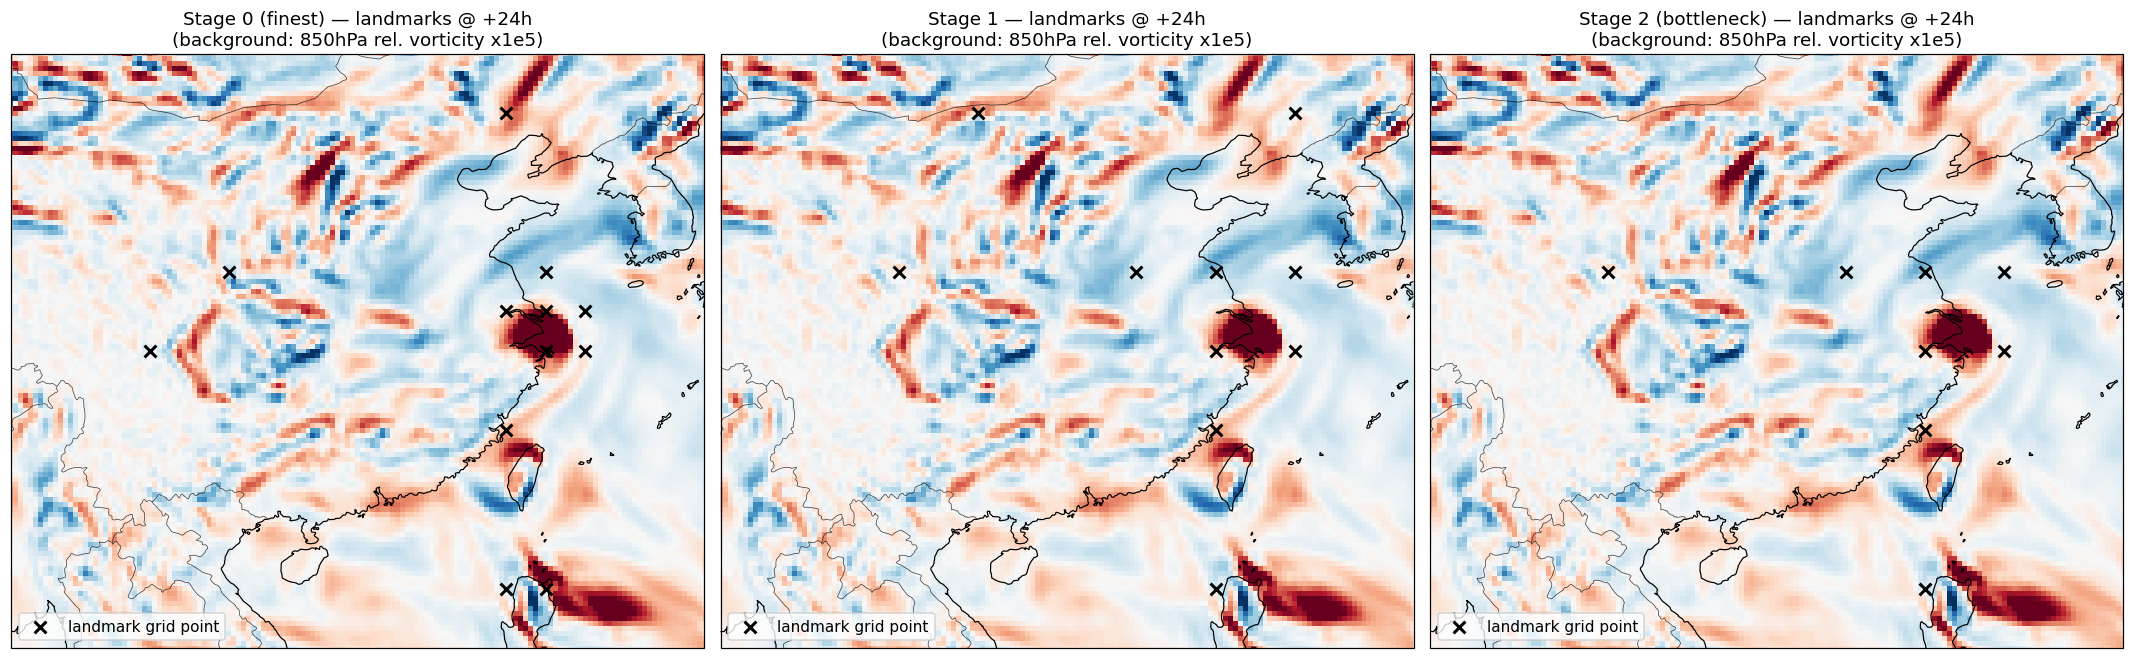

In [5]:
valid_time_24h = INIT_TIME + np.timedelta64(24, 'h')
mslp_24, z850_24, u850_24, v850_24 = get_truth_fields(valid_time_24h)
vort_24 = relative_vorticity(u850_24, v850_24, lat_full, lon_full)

fig, axes = plt.subplots(1, len(stages), figsize=(6.5 * len(stages), 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
if len(stages) == 1:
    axes = [axes]
for ax, s in zip(axes, stages):
    lat_s, lon_s, H_s, W_s = stage_latlon(s)
    dec = [d for d in results['stages'][s] if d['lead_hours'] == 24][0]
    landmarks = dec['row_landmarks']
    lm_lat = lat_s[landmarks // W_s]
    lm_lon = lon_s[landmarks % W_s]

    ax.set_extent(CHINA_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
    im = ax.pcolormesh(lon_full, lat_full, vort_24 * 1e5, transform=ccrs.PlateCarree(),
                        cmap='RdBu_r', vmin=-15, vmax=15)
    ax.scatter(lm_lon, lm_lat, transform=ccrs.PlateCarree(), c='black', s=60, marker='x',
               linewidths=2, label='landmark grid point')
    ax.set_title(f'{STAGE_LABELS[s]} — landmarks @ +24h\n(background: 850hPa rel. vorticity x1e5)')
    ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/landmarks_on_vorticity_24h.png', dpi=150, bbox_inches='tight')
plt.show()

Check: do landmark grid points cluster near the vorticity extremum (storm center) rather
than being spread uniformly? That would indicate the model treats the storm core as a
structurally distinct/load-bearing location for reconstructing the whole regional hidden
state — a different phenomenon from advection (which is about *directional* attention, not
*which locations act as anchors*).

## 3. Do landmarks track the storm as it moves?

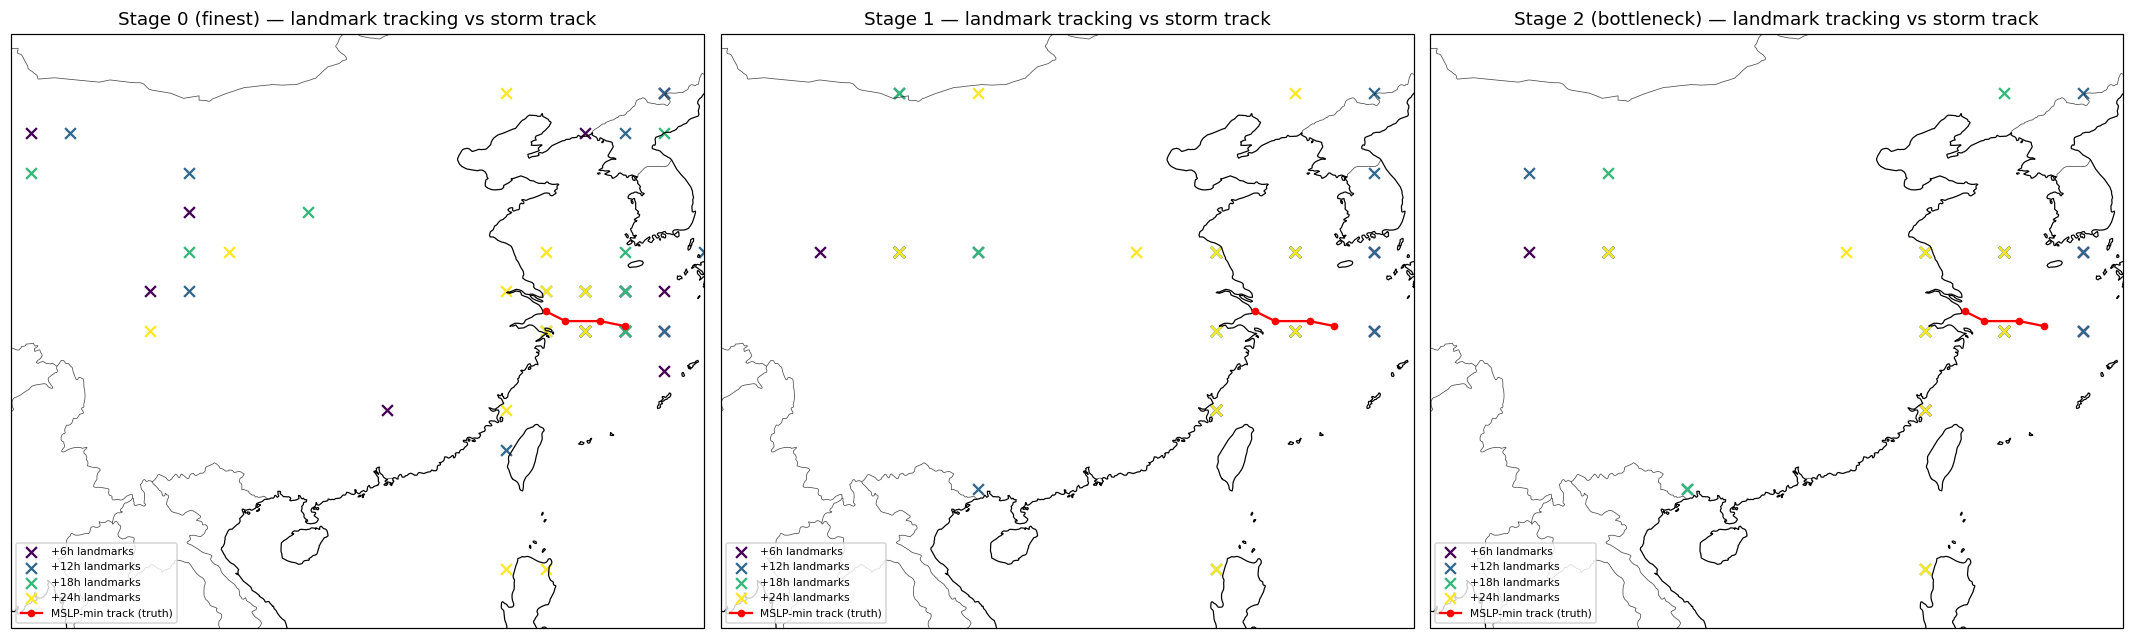

In [6]:
fig, axes = plt.subplots(1, len(stages), figsize=(6.5 * len(stages), 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
if len(stages) == 1:
    axes = [axes]
cmap = plt.cm.viridis
for ax, s in zip(axes, stages):
    lat_s, lon_s, H_s, W_s = stage_latlon(s)
    ax.set_extent(CHINA_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
    mslp_min_track = []
    for i, lead in enumerate(LEAD_HOURS_LIST):
        valid_time = INIT_TIME + np.timedelta64(int(lead), 'h')
        mslp, *_ = get_truth_fields(valid_time)
        lat_mask = (lat_full >= CHINA_EXTENT[2]) & (lat_full <= CHINA_EXTENT[3])
        lon_mask = (lon_full >= CHINA_EXTENT[0]) & (lon_full <= CHINA_EXTENT[1])
        sub = mslp[np.ix_(lat_mask, lon_mask)]
        iy, ix = np.unravel_index(np.argmin(sub), sub.shape)
        mslp_min_track.append((lon_full[lon_mask][ix], lat_full[lat_mask][iy]))

        dec = [d for d in results['stages'][s] if d['lead_hours'] == lead][0]
        landmarks = dec['row_landmarks']
        lm_lat = lat_s[landmarks // W_s]
        lm_lon = lon_s[landmarks % W_s]
        color = cmap(i / max(len(LEAD_HOURS_LIST) - 1, 1))
        ax.scatter(lm_lon, lm_lat, transform=ccrs.PlateCarree(), color=color, s=50, marker='x',
                   label=f'+{lead}h landmarks')
    track_lon, track_lat = zip(*mslp_min_track)
    ax.plot(track_lon, track_lat, transform=ccrs.PlateCarree(), color='red', marker='o',
            markersize=4, linewidth=1.5, label='MSLP-min track (truth)')
    ax.set_title(f'{STAGE_LABELS[s]} — landmark tracking vs storm track')
    ax.legend(loc='lower left', fontsize=7)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/landmark_tracking_vs_storm.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Residual map — where the skeleton approximation fails most

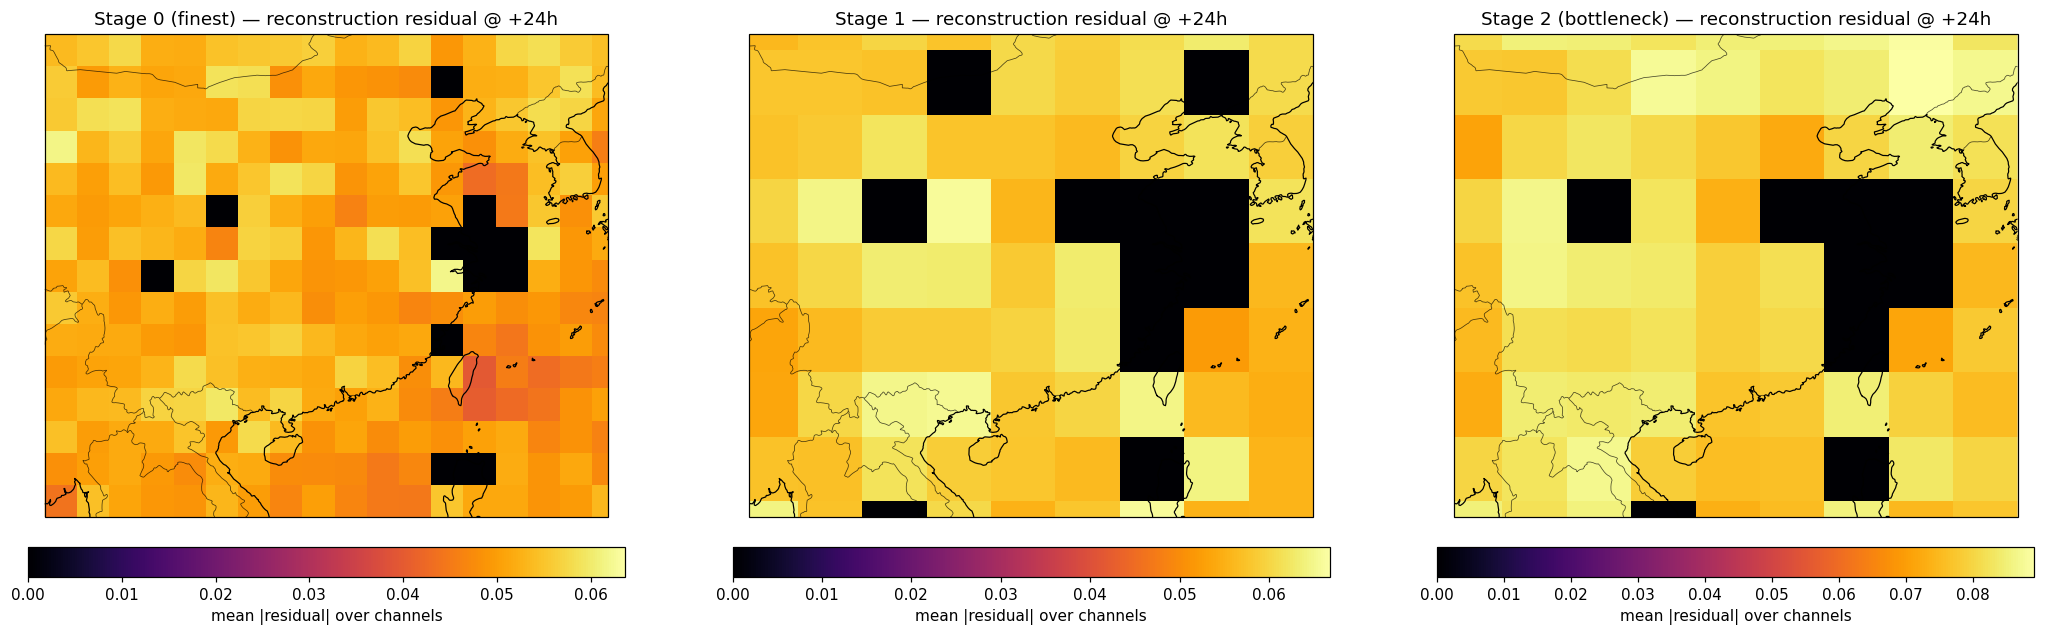

In [7]:
fig, axes = plt.subplots(1, len(stages), figsize=(6.5 * len(stages), 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
if len(stages) == 1:
    axes = [axes]
for ax, s in zip(axes, stages):
    lat_s, lon_s, H_s, W_s = stage_latlon(s)
    dec = [d for d in results['stages'][s] if d['lead_hours'] == 24][0]
    residual_map = np.abs(dec['row_residual']).mean(axis=-1).reshape(H_s, W_s)

    ax.set_extent(CHINA_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
    im = ax.pcolormesh(lon_s, lat_s, residual_map, transform=ccrs.PlateCarree(), cmap='inferno')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.85,
                 label='mean |residual| over channels')
    ax.set_title(f'{STAGE_LABELS[s]} — reconstruction residual @ +24h')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/residual_map_24h.png', dpi=150, bbox_inches='tight')
plt.show()

High-residual regions are where the `k=24`-landmark row skeleton fails to explain the hidden
state — i.e. where the representation is genuinely high-rank/complex given this budget. If
this concentrates around the storm rather than being spread uniformly, it says the model
spends disproportionately more of its "unique" representational capacity there (consistent
with a convectively active, highly nonlinear region) — useful signal for *where* a
landmark-based sparse-rollout scheme would need a larger local landmark budget to stay
accurate, versus where the field is redundant enough to compress hard.

## Summary / next steps

- **What we found**: reconstruction fidelity of the row/column skeleton as a function of
  stage depth and lead time (Section 1); whether landmark grid points concentrate at
  physically meaningful features — storm core, vorticity extremum — rather than scattering
  uniformly (Section 2); whether those landmarks move with the storm across the rollout,
  which would be a *different* kind of "the model tracks the storm" evidence than the
  Advection Heads' attention-offset result (Section 3); and where the low-rank approximation
  breaks down hardest (Section 4).
- **Efficiency angle**: if a small `k` reconstructs the hidden state with acceptable fidelity
  at a given stage, a rollout could propagate only the landmark tokens forward instead of the
  full grid — directly relevant to the ~8GB unexplained overhead we measured in
  `aurora.rollout()` versus calling `model.forward()` directly. Landmarks also give a
  principled, cheap-to-compute sampling grid for future occlusion experiments (instead of the
  full-grid occlusion used in notebook 02).
- **Possible follow-ups**: sweep `k`; correlate column-skeleton (landmark channel) time series
  against named physical diagnostics (vorticity, moisture flux, thickness) to see whether any
  channel is nameable; repeat for a "quiet" (non-typhoon) case as a control, the same way
  notebook 02 used a quiet baseline to rule out an orography artifact.